In [9]:
import os
import numpy as np
import itertools
import math, random
random.seed = 42

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils

from pathlib import Path
import scipy.spatial.distance
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [10]:
path = Path("sources/ModelNet10")

folders = [dir for dir in sorted(os.listdir(path)) if os.path.isdir(path/dir)]
classes = {folder: i for i, folder in enumerate(folders)}
classes

{'bathtub': 0,
 'bed': 1,
 'chair': 2,
 'desk': 3,
 'dresser': 4,
 'monitor': 5,
 'night_stand': 6,
 'sofa': 7,
 'table': 8,
 'toilet': 9}

In [11]:
id2cls = {i: folder for folder, i in classes.items()}
id2cls

{0: 'bathtub',
 1: 'bed',
 2: 'chair',
 3: 'desk',
 4: 'dresser',
 5: 'monitor',
 6: 'night_stand',
 7: 'sofa',
 8: 'table',
 9: 'toilet'}

### Utility Functions

Формат **OFF (Object File Format)** описывает трёхмерную модель в виде **вершин** и **граней** (faces), то есть это классическое *поверхностное представление* (surface mesh).

Первая строка всегда содержит слово `OFF`.
Вторая — три целых числа:

```
n_verts n_faces n_edges
```

* **verts (vertices)** — это список трёхмерных координат точек (вершин сетки). Каждая строка — три числа `x y z`. Всего таких строк `n_verts`.
  Пример:

  ```
  -1.0  0.5  0.3
   0.7 -0.8  0.4
  ```

  Это реальные координаты точек в трёхмерном пространстве.

* **faces** — это список граней, каждая грань задаётся номерами вершин, которые её образуют.
  В строке сначала стоит количество вершин в грани (обычно 3 — для треугольников), а дальше идут индексы этих вершин (индексация с нуля).
  Например:

  ```
  3 0 1 2
  ```

  означает грань, построенную по вершинам с индексами 0, 1 и 2.

* **edges** — это количество рёбер (line segments) в модели, но оно **не используется** при чтении данных. Это просто информация для справки — число рёбер можно вычислить из faces, если нужно.

Итого, OFF-файл хранит:

1. **список вершин** — набор координат точек;
2. **список граней** — набор индексов, которые указывают, какие вершины соединяются, чтобы образовать поверхность;
3. **число рёбер** — дополнительное поле, которое обычно игнорируется.

По сути, OFF описывает многоугольную сетку (mesh): вершины — это геометрия, faces — топология (связи между ними).


| Раздел    | Пример                          | Значение                                |
| --------- | ------------------------------- | --------------------------------------- |
| Заголовок | `OFF`                           | Метка формата                           |
| Параметры | `1568 1820 0`                   | 1568 вершин, 1820 граней, 0 рёбер       |
| Вершины   | `-13.166650 37.190785 5.729000` | Координаты точки                        |
| …         | *(ещё 1567 строк)*              | Остальные вершины                       |
| Грани     | `3 0 1 2`                       | Индексы вершин, формирующих треугольник |
| …         | *(ещё 1819 строк)*              | Остальные грани                         |


In [12]:
def read_off(file):
    if 'OFF' != file.readline().strip():
        raise('Not a valid OFF header')
    n_verts, n_faces, __ = tuple([int(s) for s in file.readline().strip().split(' ')])
    verts = [[float(s) for s in file.readline().strip().split(' ')] for i_vert in range(n_verts)]
    faces = [[int(s) for s in file.readline().strip().split(' ')][1:] for i_face in range(n_faces)]
    return verts, faces


def visualize_rotate(data):
    x_eye, y_eye, z_eye = 1.25, 1.25, 0.8
    frames=[]

    def rotate_z(x, y, z, theta):
        w = x+1j*y
        return np.real(np.exp(1j*theta)*w), np.imag(np.exp(1j*theta)*w), z

    for t in np.arange(0, 10.26, 0.1):
        xe, ye, ze = rotate_z(x_eye, y_eye, z_eye, -t)
        frames.append(dict(layout=dict(scene=dict(camera=dict(eye=dict(x=xe, y=ye, z=ze))))))
    fig = go.Figure(data=data,
        layout=go.Layout(
            updatemenus=[dict(type='buttons',
                showactive=False,
                y=1,
                x=0.8,
                xanchor='left',
                yanchor='bottom',
                pad=dict(t=45, r=10),
                buttons=[dict(label='Play',
                    method='animate',
                    args=[None, dict(frame=dict(duration=50, redraw=True),
                        transition=dict(duration=0),
                        fromcurrent=True,
                        mode='immediate'
                        )]
                    )
                ])]
        ),
        frames=frames
    )

    return fig


def pcshow(xs,ys,zs):
    data=[go.Scatter3d(x=xs, y=ys, z=zs,
                                   mode='markers')]
    fig = visualize_rotate(data)
    fig.update_traces(marker=dict(size=2,
                      line=dict(width=2,
                      color='DarkSlateGrey')),
                      selector=dict(mode='markers'))
    fig.show()

def plot_point_cloud(points, color=None, size=2, title="Point Cloud"):

    if isinstance(points, torch.Tensor):
        pts = points.detach().cpu().numpy()
    else:
        pts = np.asarray(points)

    if pts.ndim != 2 or (pts.shape[1] != 3 and pts.shape[0] != 3):
        raise ValueError(f"Ожидается массив формы (N,3) или (3,N), получено {pts.shape}")
    if pts.shape[1] != 3:
        pts = pts.T

    x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]

    marker_kwargs = dict(size=size, opacity=0.9)
    if color is None:
        marker_kwargs["color"] = "royalblue"
    else:
        marker_kwargs["color"] = color

    scatter = go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=marker_kwargs
    )
    fig = go.Figure(data=[scatter])
    fig.update_layout(
        title=title,
        scene=dict(aspectmode='data'),
        margin=dict(l=0, r=0, t=30, b=0)
    )
    
    fig.show()

In [13]:
with open(path/"sofa/train/sofa_0002.off", 'r') as f:
    verts, faces = read_off(f)
    
i,j,k = np.array(faces).T
x,y,z = np.array(verts).T
len(x)

6433

In [14]:
visualize_rotate([go.Mesh3d(x=x, y=y, z=z, color='yellowgreen', opacity=0.50, i=i,j=j,k=k)]).show()

In [15]:
visualize_rotate([go.Scatter3d(x=x, y=y, z=z, mode='markers')]).show()

In [16]:
pcshow(x,y,z)

### Преобразования облаков точек

На этом этапе данные из формата OFF (треугольные меши) преобразуются в формат, который может принимать на вход сеть PointNet — облако точек (point cloud).  
Для этого реализуются последовательные преобразования (transforms), каждое из которых отвечает за отдельный шаг подготовки: выбор точек с поверхности, нормализация, аугментации и приведение к тензору PyTorch.

#### 1. Семплирование точек с поверхности (`PointSampler`)

Изначально каждая модель представляет собой треугольную сетку — множество вершин и граней, которые образуют поверхность объекта.  
PointNet не работает напрямую с такими сетками, а требует на вход облако точек: набор координат, равномерно распределённых по поверхности.  

Для этого используется равновероятное семплирование точек, пропорциональное площади треугольников.  
Площадь каждой грани вычисляется по векторам рёбер:

$$
S = \frac{1}{2}\|(\mathbf{p}_2 - \mathbf{p}_1) \times (\mathbf{p}_3 - \mathbf{p}_1)\|,
$$

а вероятность выбора конкретной грани равна

$$
P(i) = \frac{S_i}{\sum_j S_j}.
$$

После выбора грани внутри неё берётся случайная точка по барицентрическим координатам:

$$
\mathbf{P} = s\mathbf{A} + (t - s)\mathbf{B} + (1 - t)\mathbf{C}, \quad s,t \sim U(0,1), \ s \le t.
$$

Такое построение обеспечивает **равномерное распределение точек по площади поверхности**, а не по количеству граней.

В результате `PointSampler(1024)` превращает модель в облако из 1024 точек $(x,y,z)$.

---

# Что такое барицентрические координаты


Барицентрические координаты — это способ задать точку внутри треугольника через веса его вершин.

## Основная идея

Пусть у нас есть треугольник с вершинами $A$, $B$ и $C$ в пространстве. Тогда любая точка $P$ внутри этого треугольника может быть выражена как:


$$
P = \alpha A + \beta B + \gamma C,
$$

где коэффициенты $\alpha$, $\beta$, $\gamma$ удовлетворяют условиям:


$$
\alpha + \beta + \gamma = 1, \\
\alpha, \beta, \gamma \geq 0.
$$

Эти три числа $(\alpha, \beta, \gamma)$ — и есть **барицентрические координаты** точки $P$ относительно треугольника $ABC$.

## Интуитивная интерпретация

Если представить, что в вершинах треугольника размещены массы $\alpha$, $\beta$ и $\gamma$, то точка $P$ будет **центром масс** этой системы.

## Практическая польза

Барицентрические координаты позволяют:
- равномерно генерировать точки внутри треугольника;
- выполнять линейную интерполяцию значений (например, цветов или нормалей) по вершинам;
- определять принадлежность точки треугольнику (если все координаты $\in [0,1]$, точка внутри).


## Эффективный способ генерации случайных точек


Хотя можно брать случайные $\alpha, \beta, \gamma$ из $[0,1]$ и нормировать их, существует более простой и вычислительно устойчивый метод:


$$
P = sA + (t - s)B + (1 - t)C,
$$

где:
- $s, t \sim U(0,1)$ — случайные числа из равномерного распределения;
- $s \leq t$ — условие, обеспечивающее корректность координат.


В этой формуле:
- $s$ играет роль $\alpha$;
- $(t - s)$ — роль $\beta$;
- $(1 - t)$ — роль $\gamma$.

Такой подход гарантирует:
1. Равномерное распределение точек по площади треугольника.
2. Автоматическое выполнение условий $\alpha + \beta + \gamma = 1$ и $\alpha, \beta, \gamma \geq 0$.
3. Отсутствие необходимости в дополнительной нормировке.
---

In [17]:
class PointSampler(object):
    def __init__(self, output_size):
        assert isinstance(output_size, int)
        self.output_size = output_size
    
    def triangle_area(self, pt1, pt2, pt3):
        side_a = np.linalg.norm(pt1 - pt2)
        side_b = np.linalg.norm(pt2 - pt3)
        side_c = np.linalg.norm(pt3 - pt1)
        s = 0.5 * ( side_a + side_b + side_c)
        return max(s * (s - side_a) * (s - side_b) * (s - side_c), 0)**0.5

    def sample_point(self, pt1, pt2, pt3):
        # barycentric coordinates on a triangle
        # https://mathworld.wolfram.com/BarycentricCoordinates.html
        s, t = sorted([random.random(), random.random()])
        f = lambda i: s * pt1[i] + (t-s)*pt2[i] + (1-t)*pt3[i]
        return (f(0), f(1), f(2))
        
    
    def __call__(self, mesh):
        verts, faces = mesh
        verts = np.array(verts)
        areas = np.zeros((len(faces)))

        for i in range(len(areas)):
            areas[i] = (self.triangle_area(verts[faces[i][0]],
                                           verts[faces[i][1]],
                                           verts[faces[i][2]]))
            
        sampled_faces = (random.choices(faces, 
                                      weights=areas,
                                      cum_weights=None,
                                      k=self.output_size))
        
        sampled_points = np.zeros((self.output_size, 3))

        for i in range(len(sampled_faces)):
            sampled_points[i] = (self.sample_point(verts[sampled_faces[i][0]],
                                                   verts[sampled_faces[i][1]],
                                                   verts[sampled_faces[i][2]]))
        
        return sampled_points

In [18]:
pointcloud = PointSampler(3000)((verts, faces))
pcshow(*pointcloud.T)

#### 2. Нормализация (`Normalize`)

Следующий шаг — привести все объекты к единому масштабу и центру.  
Сначала вычитается центр масс облака:

$$
\bar{\mathbf{P}} = \frac{1}{N}\sum_i \mathbf{P}_i,
$$

затем каждая точка масштабируется так, чтобы объект целиком вписался в единичную сферу:

$$
\tilde{\mathbf{P}}_i = \frac{\mathbf{P}_i - \bar{\mathbf{P}}}{\max_j \|\mathbf{P}_j - \bar{\mathbf{P}}\|}.
$$

После нормализации облако точек всегда имеет центр в начале координат и радиус, не превышающий 1.  
Это стабилизирует обучение, исключая зависимость от реальных размеров и положения объектов.

In [19]:
class Normalize(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2
        
        norm_pointcloud = pointcloud - np.mean(pointcloud, axis=0) 
        norm_pointcloud /= np.max(np.linalg.norm(norm_pointcloud, axis=1))

        return  norm_pointcloud

In [20]:
norm_pointcloud = Normalize()(pointcloud)
pcshow(*norm_pointcloud.T)

#### 3. Аугментации (`RandRotation_z` и `RandomNoise`)

Для обучающих данных вводятся стохастические преобразования, которые расширяют пространство примеров и повышают обобщающую способность модели.

**Случайный поворот вокруг оси z:**

$$
R_z(\theta) =
\begin{pmatrix}
\cos\theta & -\sin\theta & 0\\
\sin\theta &  \cos\theta & 0\\
0 & 0 & 1
\end{pmatrix},
\quad \theta \sim U(0, 2\pi).
$$

Каждая точка преобразуется как $\mathbf{P}' = R_z(\theta)\mathbf{P}$, что обеспечивает **инвариантность к ориентации объекта**.

**Добавление шума:**

$$
\mathbf{P}'_i = \mathbf{P}_i + \varepsilon_i, \quad
\varepsilon_i \sim \mathcal{N}(0, 0.02^2).
$$

Такой гауссов шум имитирует неточности сканирования или реконструкции и делает сеть менее чувствительной к артефактам.

In [21]:
class RandRotation_z(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        theta = random.random() * 2. * math.pi
        rot_matrix = np.array([[ math.cos(theta), -math.sin(theta),    0],
                               [ math.sin(theta),  math.cos(theta),    0],
                               [0,                             0,      1]])
        
        rot_pointcloud = rot_matrix.dot(pointcloud.T).T
        return  rot_pointcloud
    
class RandomNoise(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        noise = np.random.normal(0, 0.02, (pointcloud.shape))
    
        noisy_pointcloud = pointcloud + noise
        return  noisy_pointcloud

In [22]:
rot_pointcloud = RandRotation_z()(norm_pointcloud)
noisy_rot_pointcloud = RandomNoise()(rot_pointcloud)
pcshow(*noisy_rot_pointcloud.T)

#### 4. Преобразование в тензор (`ToTensor`)

Завершающий этап препроцессинга — перевод NumPy-массивов в формат `FloatTensor`, чтобы данные можно было передавать в PyTorch-модель и обрабатывать на GPU.

In [23]:
class ToTensor(object):
    def __call__(self, pointcloud):
        assert len(pointcloud.shape)==2

        return torch.from_numpy(pointcloud)

## 5. Комбинированные пайплайны

Для разных этапов обучения используются разные комбинации преобразований:

- **Тренировка** (`train_transforms`):  
  семплирование → нормализация → поворот → шум → преобразование в тензор.
- **Валидация и тест** (`default_transforms`):  
  только семплирование, нормализация и приведение к тензору.

Таким образом, каждая модель после препроцессинга представляется как тензор размерности `(1024, 3)`, где каждая строка — координаты точки, равномерно взятой с поверхности нормализованного объекта.

In [24]:
train_transforms = transforms.Compose([
                    PointSampler(1024),
                    Normalize(),
                    RandRotation_z(),
                    RandomNoise(),
                    ToTensor()
                    ])

In [25]:
def default_transforms():
    return transforms.Compose([
                                PointSampler(1024),
                                Normalize(),
                                ToTensor()
                              ])

### Класс датасета `PointCloudData`

После определения всех преобразований необходимо объединить их в единый интерфейс,
который будет предоставлять готовые образцы модели при обращении из `DataLoader`.
Эту роль выполняет класс `PointCloudData`, наследник `torch.utils.data.Dataset`.

---

#### 1. Назначение и структура

Каждый объект датасета ModelNet10 хранится в виде файла формата `.off`
в каталоге, соответствующем его классу (например, `chair/train/chair_0001.off`).
Класс `PointCloudData` реализует:

- поиск всех таких файлов по подкаталогам;
- сопоставление имён классов с числовыми метками;
- чтение и преобразование модели в облако точек с помощью заранее созданных трансформов;
- интерфейс `__getitem__`, который возвращает пару
  **(облако точек, метка класса)**.

---

#### 2. Инициализация

При создании экземпляра задаются:

- `root_dir` — путь к корню датасета (`ModelNet10`);
- `folder` — подпапка (`"train"` или `"test"`);
- `transform` — конвейер преобразований (`train_transforms` или `default_transforms`);
- параметр `valid` позволяет переключать режим валидации.

Во время инициализации конструктор:

1. считывает список всех классов и создаёт словарь  
   `self.classes = {'chair': 0, 'table': 1, ...}`;
2. проходит по каждому классу и собирает пути ко всем файлам `.off`  
   в нужной подпапке (`train` или `test`);
3. сохраняет их как список словарей вида  
   `{'pcd_path': path/to/file.off, 'category': 'chair'}`.

---

#### 3. Метод `__len__`

Возвращает длину датасета — количество файлов `.off`,
чтобы `DataLoader` мог вычислять количество батчей в эпохе.

---

#### 4. Метод `__getitem__`

Этот метод вызывается при каждой итерации загрузчика данных.
Он выполняет полный цикл подготовки одного образца:

1. **Открывает OFF-файл.**  
   С помощью функции `read_off` извлекаются вершины и грани.

2. **Применяет трансформации.**  
   Кортеж `(verts, faces)` передаётся в конвейер `self.transforms`.  
   В нём выполняются:
   - семплирование точек по площади треугольников (`PointSampler`);
   - нормализация в единичную сферу (`Normalize`);
   - при обучении — случайный поворот и шум (`RandRotation_z`, `RandomNoise`);
   - преобразование в тензор (`ToTensor`).

3. **Возвращает результат.**  
   Итоговый словарь имеет вид:
   ```python
   {
       'pointcloud': tensor(N, 3),  # координаты 1024 точек
       'category': class_index      # числовая метка
   }


In [26]:
class PointCloudData(Dataset):
    def __init__(self, root_dir, valid=False, folder="train", transform=default_transforms()):
        self.root_dir = root_dir
        folders = [dir for dir in sorted(os.listdir(root_dir)) if os.path.isdir(root_dir/dir)]
        self.classes = {folder: i for i, folder in enumerate(folders)}
        self.transforms = transform if not valid else default_transforms()
        self.valid = valid
        self.files = []
        for category in self.classes.keys():
            new_dir = root_dir/Path(category)/folder
            for file in os.listdir(new_dir):
                if file.endswith('.off'):
                    sample = {}
                    sample['pcd_path'] = new_dir/file
                    sample['category'] = category
                    self.files.append(sample)

    def __len__(self):
        return len(self.files)

    def __preproc__(self, file):
        verts, faces = read_off(file)
        if self.transforms:
            pointcloud = self.transforms((verts, faces))
        return pointcloud

    def __getitem__(self, idx):
        pcd_path = self.files[idx]['pcd_path']
        category = self.files[idx]['category']
        with open(pcd_path, 'r') as f:
            pointcloud = self.__preproc__(f)
        return {'pointcloud': pointcloud, 
                'category': self.classes[category]}

In [27]:
train_ds = PointCloudData(path, transform=train_transforms)
valid_ds = PointCloudData(path, valid=True, folder='test')

In [28]:
inv_classes = {i: cat for cat, i in train_ds.classes.items()};
inv_classes

{0: 'bathtub',
 1: 'bed',
 2: 'chair',
 3: 'desk',
 4: 'dresser',
 5: 'monitor',
 6: 'night_stand',
 7: 'sofa',
 8: 'table',
 9: 'toilet'}

In [29]:
pcd = train_ds[1000]['pointcloud']
cat = train_ds[1000]['category']
plot_point_cloud(pcd, title=f"Category: {id2cls[cat]}")

In [30]:
print('Train dataset size: ', len(train_ds))
print('Valid dataset size: ', len(valid_ds))
print('Number of classes: ', len(train_ds.classes))
print('Sample pointcloud shape: ', train_ds[0]['pointcloud'].size())
print('Class: ', inv_classes[train_ds[0]['category']])

Train dataset size:  3991
Valid dataset size:  908
Number of classes:  10
Sample pointcloud shape:  torch.Size([1024, 3])
Class:  bathtub


In [31]:
train_loader = DataLoader(dataset=train_ds, batch_size=32, shuffle=True, drop_last=True)
valid_loader = DataLoader(dataset=valid_ds, batch_size=32, drop_last=True)

### T-Net: обучаемое выравнивание координат и признаков в PointNet

В архитектуре PointNet трансформер **T-Net** выступает как обучаемый пространственный выравниватель, который снижает внутриклассовую вариативность за счёт линейного преобразования входа.

По сути, это небольшая сеть, которая по облаку точек оценивает матрицу $M \in \mathbb{R}^{k \times k}$ (с $k=3$ для координат и $k=64$ для промежуточных признаков), после чего применяет её к каждому элементу множества.

---

#### 1. Входы, выходы и применение матрицы

Пусть вход в T-Net есть тензор $X \in \mathbb{R}^{B \times k \times N}$, где:
- $B$ — размер батча,
- $N$ — число точек в объекте,
- $k$ — размерность канала (для **input T-Net** $k=3$ — координаты $x,y,z$; для **feature T-Net** $k=64$ — точечные признаки после первой свёртки).

T-Net оценивает по $X$ матрицу $M \in \mathbb{R}^{B \times k \times k}$. Преобразование применяется по канальному измерению к каждой точке:
$$
X' = M \, X, \qquad X' \in \mathbb{R}^{B \times k \times N}.
$$
То есть для каждого объекта в батче берём его $k \times N$ и слева умножаем на соответствующую $k \times k$ матрицу.

---

#### 2. Архитектура: точечные MLP + симметричная агрегация + полносвязная голова

Точечные преобразования (свёртки $1 \times 1$) извлекают локальные признаки по каждой точке независимо, затем симметричный пул (обычно **max-pool**) агрегирует их в глобальный дескриптор, и далее полносвязные слои восстанавливают параметры матрицы.

Типичная схема для $k \in \{3, 64\}$:
1. Точечные свёртки (по каналу, ядро $1$):  
   $k \to 64 \to 128 \to 1024$ с нелинейностями и BatchNorm, получаем тензор $\in \mathbb{R}^{B \times 1024 \times N}$.
2. Симметричная агрегация по множеству точек:  
   $Z = \mathrm{MAXPOOL}_N(\cdot)$ даёт глобальный вектор $\in \mathbb{R}^{B \times 1024}$.
3. Полносвязные слои:  
   $1024 \to 512 \to 256 \to k^2$, после чего выход ремапится в $\mathbb{R}^{B \times k \times k}$.
4. Стабилизирующая инициализация к тождеству*:  
   $$M = \operatorname{reshape}(\text{FC}(Z), k,k) + I_k.$$

Последний шаг — критичен: в начале обучения сеть должна вести себя нейтрально (не искажать вход), иначе градиенты уплывают. На практике часто делают **нулевую инициализацию** последнего линейного слоя и задают **bias**, равный векторизованной единичной матрице, чтобы изначально $M \approx I_k$.

Когда T-Net только начинает обучение, она ещё не умеет предсказывать корректные матрицы преобразования.  
Если разрешить ей с самого старта применять произвольные $3\times3$ (или $64\times64$) матрицы,  
то на первых итерациях сеть будет случайно вращать и растягивать входные точки — 
и вся остальная часть PointNet получит «сломанный» сигнал.

Чтобы этого избежать, выход T-Net **искусственно смещают к единичной матрице** —  
той, которая ничего не меняет. Это называется *инициализация к тождеству*.

Формула выглядит так:

$$
M = \text{reshape}(\text{FC}(Z), k, k) + I_k,
$$

где $I_k$ — единичная матрица (например, для $k=3$ это просто диагональ из 1).  
`FC(Z)` — выход последнего полносвязного слоя, который в начале обучения почти нулевой,  
поэтому $M \approx I_k$ и T-Net на старте **поведение как "ничего не трогаю"**.

Постепенно во время обучения она начинает отклоняться от единицы и выучивает  
корректные линейные выравнивания, которые реально улучшают качество.

---

#### 3. Регуляризация к ортогональности

Желательно, чтобы $M$ было близко к ортогональной матрице (поворот/отражение), а не произвольно сжимало или растягивало пространство. Это контролируется штрафом:
$$
\mathcal{R}(M) \;=\; \frac{1}{B}\sum_{b=1}^{B} \big\| I_k - M_b M_b^\top \big\|_F^2,
$$
где $\|\cdot\|_F$ — фробениусова норма. Тогда итоговая функция потерь классификации (с лог-вероятностями на выходе PointNet) принимает вид:
$$
\mathcal{L} \;=\; \underbrace{\text{NLLLoss}(\hat{y}, y)}_{\text{классификация}} \;+\; \alpha\, \mathcal{R}(M^{(3)}) \;+\; \alpha\, \mathcal{R}(M^{(64)}),
$$
где $M^{(3)}$ — матрица из input T-Net, $M^{(64)}$ — из feature T-Net, а $\alpha \ll 1$ — малый коэффициент регуляризации (например, $10^{-4}$). Такой штраф поддавливает $M$ к изометриям и предотвращает вырождение.

Теперь, когда T-Net может предсказывать любые матрицы $M$,  
возникает новая проблема — она может не просто вращать, а **растягивать и сжимать** облако точек,  
что вредит обучению: точки могут «съезжать» друг к другу, теряя форму объекта.

Чтобы ограничить это поведение, вводится штраф — регуляризация, которая заставляет матрицу $M$  
оставаться близкой к **ортогональной**, то есть вести себя как чистое вращение или отражение без масштабирования.

Математически для идеальной ортогональной матрицы выполняется:

$$
M M^\top = I.
$$

Если это не так, значит $M$ растягивает или искажает пространство.  
Поэтому в функцию потерь добавляют маленький дополнительный член:

$$
R(M) = \|I - M M^\top\|_F^2,
$$

и итоговая ошибка выглядит примерно как:

$$
L = L_\text{классификации} + \alpha \, R(M),
$$

где $\alpha$ — очень маленькое число (например, $10^{-4}$),  
которое просто слегка подталкивает матрицу к ортогональности.

Таким образом, T-Net может вращать и отражать, но не будет «сплющивать» или «растягивать» облако точек.

---

#### 4. Инвариантность и уменьшение внутриклассовой вариации

* Для входных координат ($k=3$) T-Net учится приводить облако к канонической ориентации и масштабу в смысле линейного преобразования, уменьшая разброс поз и лёгких аффинных искажений. В результате **последующие слои видят более стабильный геометрический шаблон**.

* Для признаков ($k=64$) — аналогичная логика, но уже в **пространстве точечных признаков**: T-Net устраняет избыточные линейные корреляции/перемешивания каналов, подворачивая их к удобной базе перед глобальной агрегацией. Это повышает выразительность и устойчивость сети.

Важно, что агрегация по точкам — **симметричная** (max-pool), благодаря чему порядок точек не влияет на $Z$, а T-Net, наблюдая мультисет признаков, обучается **перестановочно-инвариантному** выравниванию.

Представьте набор облаков точек одного класса,  
например, стульев, снятых под разными углами.  
Один стул может быть повернут на 30°, другой — на 180°, третий — немного наклонён.  
Для нейросети это **разные данные**, хотя человек понимает, что это один и тот же объект.

T-Net решает эту проблему автоматически.  
Она учится таким образом преобразовывать входное облако (вращать, выравнивать, чуть деформировать),  
чтобы все стулья «вставали в одну стандартную позу» — например, спинка вверх, ножки вниз.  
То же самое для кроватей, ванн и т. д.

Так сеть **уменьшает внутриклассовую вариацию** — делает примеры одного класса более похожими друг на друга  
в пространстве признаков. Благодаря этому основной классификатору (последним слоям PointNet)  
становится гораздо легче различать именно форму, а не случайную ориентацию.

---

T-Net получает на вход облако точек $X \in \mathbb{R}^{3\times N}$ и предсказывает матрицу $M \in \mathbb{R}^{3\times3}$.  
Эта матрица применяется ко всем точкам:

$$
X' = M X.
$$

То есть T-Net «поворачивает» и «выравнивает» объект в пространстве.  
Она делает это не по отдельной команде, а потому что через неё проходит градиент от основной ошибки классификации:  
если поворот улучшает распознавание, веса T-Net подстраиваются, чтобы выдавать такое $M$ чаще.

---

1. **Инициализация.**  
В начале обучения $M$ задаётся близкой к единичной матрице $I$ —  
чтобы сеть сначала ничего не меняла и не искажала облако.


2. **Регуляризация.**  
В функцию потерь добавляется штраф, который заставляет $M$ оставаться близкой к ортогональной:
$$
R(M) = \|I - M M^\top\|^2.
$$
Это удерживает преобразование в пределах вращения/отражения, не давая ему «растягивать» точки.



3. **Результат.**  
Со временем T-Net учится выдавать такое $M$, которое ставит объекты одного класса (например, стулья) в примерно одинаковое положение.  
Это уменьшает разброс ориентаций и помогает PointNet различать именно форму, а не позу.



**Проще говоря:**

Предположим, на вход подаётся облако точек $X \in \mathbb{R}^{3\times N}$ — набор координат $(x, y, z)$.

T-Net предсказывает матрицу $M \in \mathbb{R}^{3\times3}$  
и применяет её к этим точкам:

$$
X' = M X.
$$

Это означает, что все точки поворачиваются, масштабируются или чуть деформируются  
одной и той же линейной трансформацией.

Весь PointNet обучается **на задаче классификации** — он получает истинную метку класса (например, “chair”)  
и минимизирует ошибку между предсказанием и реальностью.

Когда модель делает ошибку, через всю сеть (в том числе через T-Net)  
идёт **обратное распространение ошибки (backpropagation)**.  
Градиенты доходят до параметров T-Net и сообщают ей буквально следующее:

> «Если бы ты повернула этот объект чуть по-другому,  
>   остальная сеть смогла бы распознать его правильнее».

T-Net изменяет свои веса так, чтобы в следующий раз выдать другое $M$,  
которое *улучшит итоговую классификацию*.

---

#### 5. Размерности и поток данных

Для **input T-Net** ($k=3$):
- Вход: $X \in \mathbb{R}^{B \times 3 \times N}$.
- Точечный блок: $3 \to 64 \to 128 \to 1024$ (через $1\times1$ свёртки).
- Агрегация: $\mathrm{MAXPOOL}_N \Rightarrow \mathbb{R}^{B \times 1024}$.
- Полносвязный блок: $1024 \to 512 \to 256 \to 9$.
- Ремап: $9 \mapsto 3 \times 3$, затем $M^{(3)} = \text{mat} + I_3$.
- Применение: $X' = M^{(3)} X$.

Для **feature T-Net** ($k=64$):
- Вход: $X^{(64)} \in \mathbb{R}^{B \times 64 \times N}$ (после первой свёртки PointNet).
- Аналогично: $64 \to 64 \to 128 \to 1024$ → max-pool → FC → $64^2$ → $M^{(64)} + I_{64}$.
- Применение: $X^{(64)\prime} = M^{(64)} X^{(64)}$.

---

#### 6. Замечания по устойчивости

1. **Инициализация к $I_k$** — Без неё T-Net в начале может ломать вход, что усложняет оптимизацию. Нулевая инициализация последнего FC-слоя и bias, равный $\operatorname{vec}(I_k)$, — надёжная схема.

2. **Регуляризация ортогональности** не должна быть слишком сильной: большой $\alpha$ сожмёт пространство решений к чистым поворотам и может ограничить полезные выравнивания (например, лёгкие анизотропные растяжения). Значения порядка $10^{-4}$–$10^{-3}$ работают стабильно.

3. **Градиенты через max-pool.** В агрегаторе max-пулинг направляет градиент только через максимальные точки/каналы. Это не проблема для T-Net: у него достаточно параметров выше по потоку (точечные свёртки) и ниже (FC), чтобы получать информативные сигналы.

---

#### 7. Контекст в полном PointNet

Полный путь данных в начале сети:
1. $X \in \mathbb{R}^{B \times 3 \times N}$ подаётся в **input T-Net**, получаем $M^{(3)}$ и $X' = M^{(3)} X$.
2. Точечные свёртки: $3 \to 64$, образуя $X^{(64)}$.
3. **feature T-Net** выдаёт $M^{(64)}$ и выравнивает признаки: $X^{(64)\prime} = M^{(64)} X^{(64)}$.
4. Далее $64 \to 128 \to 1024$, max-pool по $N$, полносвязный классификатор $1024 \to 512 \to 256 \to C$.

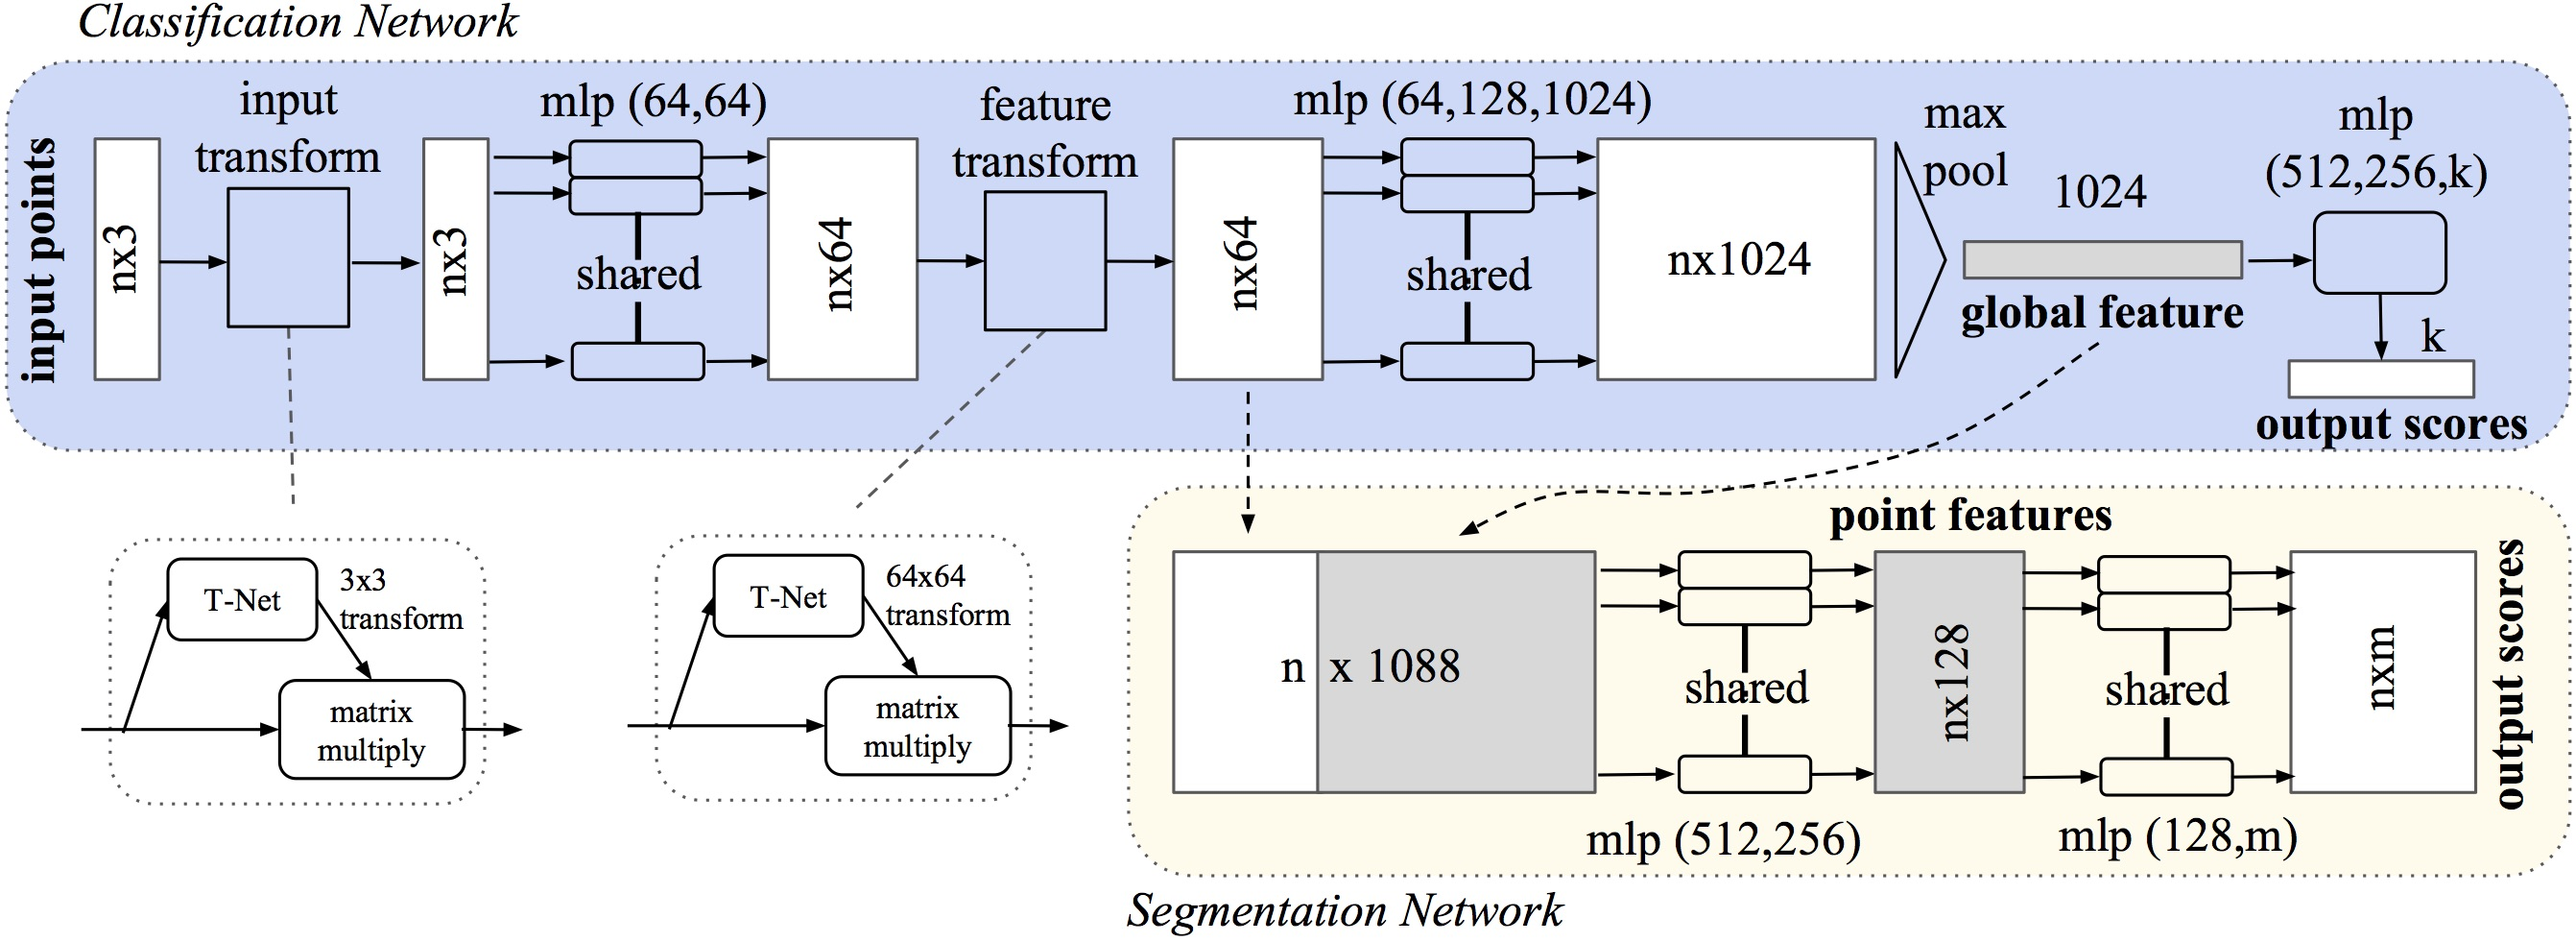

In [32]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

#### T-net

In [33]:
class Tnet(nn.Module):
    def __init__(self, k=3):
        super().__init__()
        self.k = k

        # Convolutional Layers (Feature Extraction)
        self.conv1 = nn.Conv1d(k, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)

        # Normalize activations to stabilize training and accelerate convergence
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

        # Fully Connected Layers (Regression)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k * k)

        # Normalize activations to stabilize training and accelerate convergence
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)

        # Weight Initialization
        nn.init.constant_(self.fc3.weight, 0)
        nn.init.constant_(self.fc3.bias, 0)

    def forward(self, x):
        batchsize = x.size(0)

        x = F.relu(self.bn1(self.conv1(x))) # (batch, 64, num_points)
        x = F.relu(self.bn2(self.conv2(x))) # (batch, 128, num_points)
        x = F.relu(self.bn3(self.conv3(x))) # (batch, 1024, num_points)

        # Max pooling across all points to get a global feature vector
        x = torch.max(x, 2)[0]  # (batch, 1024)

        # Matrix Regression
        x = F.relu(self.bn4(self.fc1(x)))   # (batch, 512)
        x = F.relu(self.bn5(self.fc2(x)))   # (batch, 256)

        x = self.fc3(x)                    # (batch, k*k)

        # Add Identity Matrix
        id_matrix = torch.eye(self.k, device=x.device).view(1, self.k * self.k)
        x = x + id_matrix.repeat(batchsize, 1)  # (batch, k*k)

        # Reshape to Matrix
        x = x.view(-1, self.k, self.k)
        return x

#### Transform

In [34]:
class Transform(nn.Module):
    def __init__(self, bs=32):
        super().__init__()
        self.input_transform = Tnet(k=3)
        self.feature_transform = Tnet(k=64)
        self.conv1 = nn.Conv1d(3,64,1)

        self.conv2 = nn.Conv1d(64,128,1)
        self.conv3 = nn.Conv1d(128,1024,1)


        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

    def forward(self, input):
        matrix3x3 = self.input_transform(input)
        # batch matrix multiplication
        xb = torch.bmm(matrix3x3, input)

        xb = F.relu(self.bn1(self.conv1(xb)))

        matrix64x64 = self.feature_transform(xb)
        xb = torch.bmm(matrix64x64, xb)

        xb = F.relu(self.bn2(self.conv2(xb)))
        xb = self.bn3(self.conv3(xb))
        xb = nn.MaxPool1d(xb.size(-1))(xb)
        output = nn.Flatten(1)(xb)
        return output, matrix3x3, matrix64x64

#### PointNet

In [35]:
class PointNet(nn.Module):
    def __init__(self, classes=10, bs=32):
        super().__init__()
        self.transform = Transform(bs)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, classes)
        

        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.3)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, input):
        xb, matrix3x3, matrix64x64 = self.transform(input)
        xb = F.relu(self.bn1(self.fc1(xb)))
        xb = F.relu(self.bn2(self.dropout(self.fc2(xb))))
        output = self.fc3(xb)
        return self.logsoftmax(output), matrix3x3, matrix64x64

### Loss-функция PointNet



Функция потерь в PointNet выглядит так:

$$
\mathcal{L} = \mathcal{L}_\text{class} + \alpha \, \mathcal{L}_\text{ortho},
$$

где  
- $\mathcal{L}_\text{class}$ — это обычная ошибка классификации,  
- $\mathcal{L}_\text{ortho}$ — штраф, заставляющий матрицы $M$ из T-Net оставаться ортогональными,  
- $\alpha$ — весовой коэффициент (маленькое число, например $10^{-4}$),  
  регулирующий вклад штрафа.

---

#### Основная часть — классификация

Для обучения PointNet используется `LogSoftmax` на выходе и `NLLLoss` (Negative Log Likelihood Loss).

Если $p_{i,c}$ — логарифм предсказанной вероятности, что объект $i$ принадлежит классу $c$,  
а $y_i$ — истинная метка класса, то:

$$
\mathcal{L}_\text{class} = - \frac{1}{B} \sum_{i=1}^{B} \log p_{i, y_i}.
$$

Это стандартная формула: мы минимизируем отрицательный логарифм вероятности правильного класса.

---

#### Регуляризация ортогональности для T-Net

Как мы уже обсуждали, T-Net предсказывает матрицы $M^{(3)}$ и $M^{(64)}$.  
Чтобы они не растягивали и не сжимали пространство, добавляется мягкое ограничение:

$$
\mathcal{L}_\text{ortho} =
\frac{1}{B} \sum_{b=1}^{B}
\Big( \| I_3 - M^{(3)}_b {M^{(3)}_b}^\top \|_F^2 +
       \| I_{64} - M^{(64)}_b {M^{(64)}_b}^\top \|_F^2 \Big),
$$

где $\|\cdot\|_F$ — фробениусова норма (квадратная сумма элементов матрицы).  
То есть если $M$ идеально ортогональна, $M M^\top = I$, и этот член равен нулю.  
Если $M$ начинает деформировать облако, штраф растёт.

---

#### Полная функция потерь

$$
\boxed{
\mathcal{L} = \text{NLLLoss}(\hat{y}, y)
\;+\;
\alpha \big(
\| I_3 - M^{(3)} {M^{(3)}}^\top \|_F^2
+
\| I_{64} - M^{(64)} {M^{(64)}}^\top \|_F^2
\big)
}
$$

На практике $\alpha = 10^{-4}$ или $10^{-3}$ —  
этого достаточно, чтобы не допускать сильных искажений,  
но не мешать T-Net немного варьировать поворот, если это улучшает распознавание.


In [36]:
def pointnetloss(outputs, labels, m3x3, m64x64, alpha=0.00005):
    criterion = torch.nn.NLLLoss()
    bs=outputs.size(0)
    id3x3 = torch.eye(3, requires_grad=True).repeat(bs,1,1)
    id64x64 = torch.eye(64, requires_grad=True).repeat(bs,1,1)
    if outputs.is_cuda:
        id3x3=id3x3.cuda()
        id64x64=id64x64.cuda()
    diff3x3 = id3x3-torch.bmm(m3x3,m3x3.transpose(1,2))
    diff64x64 = id64x64-torch.bmm(m64x64,m64x64.transpose(1,2))
    return criterion(outputs, labels) + alpha * (torch.norm(diff3x3)+torch.norm(diff64x64)) / float(bs)

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [38]:
pointnet = PointNet()
pointnet.to(device)

# modelPath = 'sources/hw10_start_model.pth'

display(pointnet)
# if os.path.isfile(path):
#     # Load a pre-trained model if it exists
#     pointnet.load_state_dict(torch.load(modelPath))

PointNet(
  (transform): Transform(
    (input_transform): Tnet(
      (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (conv3): Conv1d(128, 1024, kernel_size=(1,), stride=(1,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (fc1): Linear(in_features=1024, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=256, bias=True)
      (fc3): Linear(in_features=256, out_features=9, bias=True)
      (bn4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (feature_transform): Tnet(
      (conv1): Conv1d(64, 64, kernel_size=(1,

In [39]:
optimizer = torch.optim.Adam(pointnet.parameters(), lr=0.001)

### Train PointNet

In [ ]:
import time
from tqdm import tqdm

def train(
    model, 
    train_loader, 
    val_loader=None, 
    epochs=1, 
    criterion=nn.CrossEntropyLoss(),
    save_path="sources/hw10_best_model.pth"
):
    """
    Enhanced training loop with progress tracking
    """
    
    # Initialize tracking variables
    train_losses = []
    val_accuracies = []
    best_val_acc = 0.0
    total_batches = len(train_loader)
    
    print("=" * 60)
    print(f"Starting training for {epochs} epochs")
    print(f"Training batches: {total_batches}")
    if val_loader:
        print(f"Validation batches: {len(val_loader)}")
    print("=" * 60)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        epoch_loss = 0.0
        batch_start_time = time.time()
        
        # Progress bar for batches
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]', leave=False)
        
        for i, data in enumerate(train_pbar):
            inputs, labels = data['pointcloud'].to(device).float(), data['category'].to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs, m3x3, m64x64 = model(inputs.transpose(1,2))
            
            # Calculate loss
            loss = pointnetloss(outputs, labels, m3x3, m64x64)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Update metrics
            running_loss += loss.item()
            epoch_loss += loss.item()
            
            # Update progress bar with current loss
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'avg_loss': f'{epoch_loss/(i+1):.4f}'  # Use epoch_loss, not running_loss
            })
            
            # Print detailed progress every few batches
            if (i + 1) % 10 == 0:  # Every 10 batches (like second function)
                avg_loss = running_loss / 10  # Average over last 10
                print(f'\n  Batch {i+1:4d}/{total_batches:4d} | '
                      f'Loss: {avg_loss:.4f} | '
                      f'Time: {time.time() - batch_start_time:.2f}s')
                running_loss = 0.0  # Reset after printing
                batch_start_time = time.time()
        
        # Calculate average training loss for the epoch
        avg_train_loss = epoch_loss / total_batches
        train_losses.append(avg_train_loss)
        
        # Validation phase (rest is the same)...
        if val_loader:
            model.eval()
            val_loss = 0.0
            correct = total = 0
            
            val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]', leave=False)
            
            with torch.no_grad():
                for data in val_pbar:
                    inputs, labels = data['pointcloud'].to(device).float(), data['category'].to(device)
                    outputs, _, _ = model(inputs.transpose(1,2))
                    
                    # Calculate validation loss
                    val_loss += criterion(outputs, labels).item()
                    
                    # Calculate accuracy
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
                    
                    # Update progress bar
                    val_pbar.set_postfix({
                        'acc': f'{100.*correct/total:.2f}%'
                    })
            
            # Calculate validation metrics
            val_acc = 100. * correct / total
            avg_val_loss = val_loss / len(val_loader)
            val_accuracies.append(val_acc)
            
            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': val_acc,
                    'train_loss': avg_train_loss,
                }, save_path)
                print(f'\n New best model saved! Accuracy: {val_acc:.2f}%')
            
            # Print epoch summary
            print(f'\nEpoch {epoch+1}/{epochs} Summary:')
            print(f'   Training Loss: {avg_train_loss:.4f}')
            print(f'   Validation Loss: {avg_val_loss:.4f}')
            print(f'   Validation Accuracy: {val_acc:.2f}%')
            print(f'   Best Validation Accuracy: {best_val_acc:.2f}%')
        
        else:
            # Save checkpoint
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': avg_train_loss,
            }, f"checkpoint_epoch_{epoch+1}.pth")
            
            print(f'\nEpoch {epoch+1}/{epochs} Summary:')
            print(f'   Training Loss: {avg_train_loss:.4f}')
        
        print("-" * 60)
    
    print("\n" + "=" * 60)
    print("Training complete!")
    if val_loader:
        print(f"Best validation accuracy: {best_val_acc:.2f}%")
        print(f"Best model saved to: {save_path}")
    print("=" * 60)
    
    return train_losses, val_accuracies

In [36]:
# Let's try on one epoch

train_losses, val_accuracies = train(
    pointnet, train_loader, val_loader=valid_loader, epochs=1
)

Starting training for 1 epochs
Training batches: 124
Validation batches: 28


Epoch 1/1 [Train]:   8%|▊         | 10/124 [00:30<06:28,  3.41s/it, loss=0.7107, avg_loss=0.7187]


  Batch   10/ 124 | Loss: 0.7187 | Time: 30.22s


Epoch 1/1 [Train]:  16%|█▌        | 20/124 [00:58<04:33,  2.63s/it, loss=0.6374, avg_loss=0.7028]


  Batch   20/ 124 | Loss: 0.6870 | Time: 28.16s


...

Epoch 1/1 [Train]:  89%|████████▊ | 110/124 [06:03<00:49,  3.57s/it, loss=0.5256, avg_loss=0.6293]


  Batch  110/ 124 | Loss: 0.4845 | Time: 32.20s


Epoch 1/1 [Train]:  97%|█████████▋| 120/124 [06:33<00:15,  3.92s/it, loss=0.7823, avg_loss=0.6437]


  Batch  120/ 124 | Loss: 0.8026 | Time: 29.61s



 New best model saved! Accuracy: 73.10%

Epoch 1/1 Summary:
   Training Loss: 0.6411
   Validation Loss: 0.8181
   Validation Accuracy: 73.10%
   Best Validation Accuracy: 73.10%
------------------------------------------------------------

Training complete!
Best validation accuracy: 73.10%
Best model saved to: sources/hw10_best_model.pth


### Test PointNet

In [42]:
pointnet = PointNet()
modelPath = 'sources/hw10_best_model.pth'

pointnet.load_state_dict(torch.load(modelPath)['model_state_dict'])
pointnet = pointnet.cuda()
pointnet

PointNet(
  (transform): Transform(
    (input_transform): Tnet(
      (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (conv3): Conv1d(128, 1024, kernel_size=(1,), stride=(1,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (fc1): Linear(in_features=1024, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=256, bias=True)
      (fc3): Linear(in_features=256, out_features=9, bias=True)
      (bn4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (feature_transform): Tnet(
      (conv1): Conv1d(64, 64, kernel_size=(1,

In [43]:
pointnet.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for i, data in enumerate(valid_loader):
        print('Batch [%4d / %4d]' % (i+1, len(valid_loader)))
        
        inputs, labels = data['pointcloud'].float().cuda(), data['category'].float().cuda()
        outputs, _, _ = pointnet(inputs.transpose(1,2))
        _, preds = torch.max(outputs.data, 1)
        all_preds += list(preds.detach().cpu().numpy())
        all_labels += list(labels.detach().cpu().numpy())

Batch [   1 /   28]
Batch [   2 /   28]
Batch [   3 /   28]
Batch [   4 /   28]
Batch [   5 /   28]
Batch [   6 /   28]
Batch [   7 /   28]
Batch [   8 /   28]
Batch [   9 /   28]
Batch [  10 /   28]
Batch [  11 /   28]
Batch [  12 /   28]
Batch [  13 /   28]
Batch [  14 /   28]
Batch [  15 /   28]
Batch [  16 /   28]
Batch [  17 /   28]
Batch [  18 /   28]
Batch [  19 /   28]
Batch [  20 /   28]
Batch [  21 /   28]
Batch [  22 /   28]
Batch [  23 /   28]
Batch [  24 /   28]
Batch [  25 /   28]
Batch [  26 /   28]
Batch [  27 /   28]
Batch [  28 /   28]


In [44]:
cm = confusion_matrix(all_labels, all_preds)

In [45]:
print(cm)

[[30 15  1  2  0  0  0  0  1  1]
 [ 1 93  3  1  1  0  0  0  1  0]
 [ 0  2 90  0  1  0  0  1  1  5]
 [ 0  3  2 25  3  0  5  5 35  8]
 [ 0  0  0  0 40  0 18  0  1 27]
 [ 0  0  0  0  2 74  0  0  0 24]
 [ 0  0  0  0 23  1 48  0  8  6]
 [ 0 25  0  0  0  0  0 72  0  3]
 [ 0  0  0  6  0  0  0  0 94  0]
 [ 0  0  3  0  0  0  1  0  1 83]]


In [46]:
classes.keys()

dict_keys(['bathtub', 'bed', 'chair', 'desk', 'dresser', 'monitor', 'night_stand', 'sofa', 'table', 'toilet'])

In [47]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Normalized confusion matrix


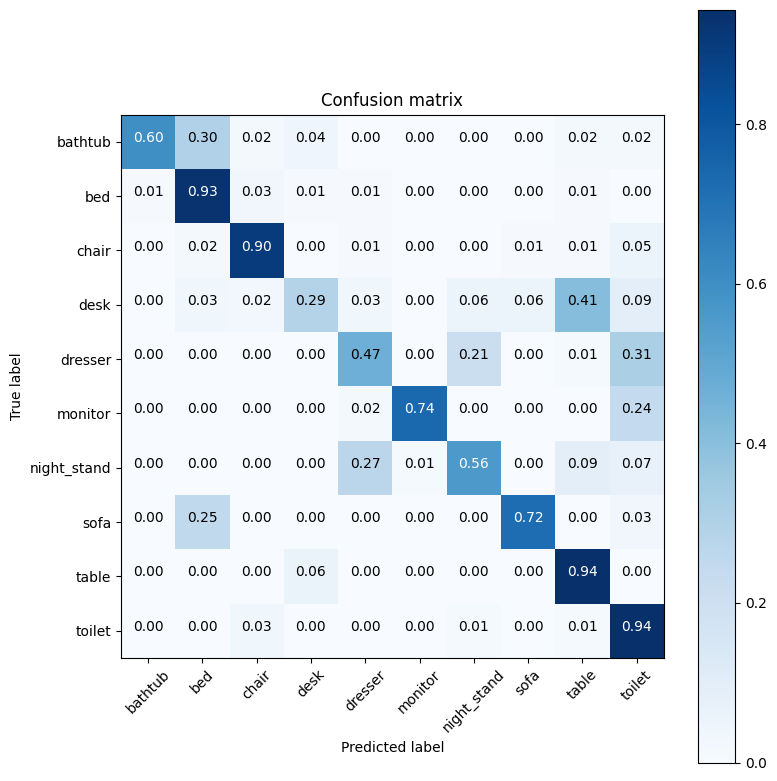

In [48]:
plt.figure(figsize=(8,8))
plot_confusion_matrix(cm, list(classes.keys()), normalize=True)

Confusion matrix, without normalization


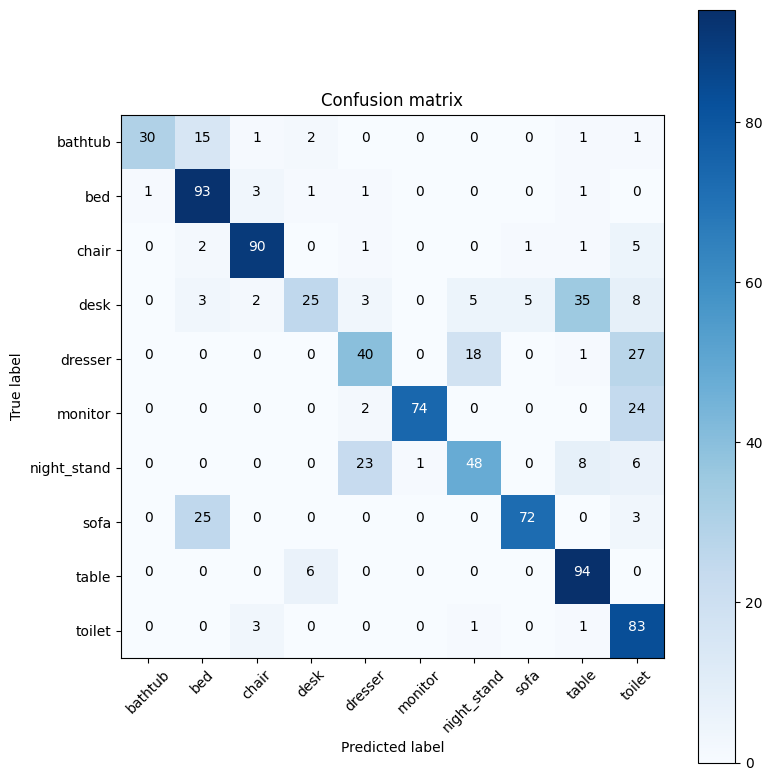

In [49]:
plt.figure(figsize=(8,8))
plot_confusion_matrix(cm, list(classes.keys()), normalize=False)

### Вывод

Процесс обучения стабилен: 
- loss уменьшался с каждой итерацией
- по итогу была достигнута валидационная точность 73.10% на одной эпохе, что соответствует ожиданиям. 
- лучшие результаты показывают классы: chair, table, sofa, bed
- классы bathtub, monitor, desk, dresser требуют дообучения
- увеличение количество эпох позволит добиться большей точности

